# The Last Inch — silent failures between the model output and the scalar

**ERA-V5 · Assignment 9 · the loss harness.** One notebook, one loss harness, and one thing
you have to get right by *reading* rather than by guessing.

Everything in language-model training funnels through three lines:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss   = cross_entropy(logits[:, :-1].reshape(-1, vocab_size),
                       tokens[:, 1:].reshape(-1))
```

This notebook takes those three lines and makes them **correct and observable**. The
uncomfortable claim it demonstrates, with numbers: **every classic bug in these lines
produces a smooth, beautiful loss curve** — two of the bugs produce *better-looking* curves
than the correct code — and no exception is ever raised. The only defenses are direct
observation: printing shapes with meanings, printing the actual token **strings** input
beside target, accounting for every token that enters the denominator, and checking the
model's *behavior* (generation), not just its scalar.

**How to read this notebook.** It runs top to bottom on CPU or GPU with no pip installs and
no downloads (Colab's stock `torch`/`numpy`/`matplotlib` are enough). Sections 3–9 are the
seven Part-1 requirements in order; Section 10 is Part 2 (a second head predicting `t+2`,
i.e. two-head multi-token prediction); Section 11 is Part 3 (the bug zoo: the warning made
quantitative). Section 12 writes every number to `submission_artifacts/` so the README can be
audited against this run.

| # | requirement | section | artifact key |
|---|---|---|---|
| 1 | every tensor shape, one line per dimension | §3 | `part1.shapes` |
| 2 | verify the shift with token **strings** | §4 | `part1.shift_audit` |
| 3 | mask padding, contributing count changes | §5 | `part1.padding` |
| 4 | pack two docs, mask the boundary, loss before/after | §6 | `part1.packing` |
| 5 | untrained perplexity ≈ vocab size | §7 | `part1.perplexity` |
| 6 | tied vs untied head parameter counts | §8 | `part1.tied_untied` |
| 7 | peak memory: ordinary vs chunked cross-entropy | §9 | `part1.memory` |
| P2 | second head predicting t+2, both losses + sum | §10 | `part2` |
| P3 | wrong-direction shift ⇒ beautiful loss curve | §11 | `part3` |

## §0 — Setup

One config cell. `A9_FAST=1` in the environment shrinks every budget (used by
`run_demo.py --fast` for smoke-testing); the committed run uses the full budgets shown in
the output below. Seed is fixed everywhere; on CPU this makes the whole notebook
bit-reproducible.

In [1]:
import json
import math
import os
import random
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

FAST = os.environ.get("A9_FAST", "") == "1"
SEED = 1337
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {
    "d_model": 128, "n_layer": 2, "n_head": 4, "max_pos": 512,
    "T": 64 if FAST else 128,          # context length
    "B": 4 if FAST else 8,             # batch size
    "steps_zoo": 40 if FAST else 300,  # per bug-zoo arm (incl. the correct arm)
    "steps_part2": 60 if FAST else 600,
    "lr": 3e-3,
    "log_every": 10 if FAST else 20,
    "mem_rows": 2048 if FAST else 4096,     # N for the memory experiment
    "mem_vocab": 32768 if FAST else 50257,  # full mode: the GPT-2 vocabulary
    "chunk_rows": 128,
}

ART = Path(os.environ.get("A9_ART_DIR", "submission_artifacts"))
RESULTS = {"config": {**CFG, "seed": SEED, "device": DEVICE, "fast": FAST,
                      "torch": torch.__version__}}
HEADLINE = {}   # name -> formatted string; the README must quote these verbatim
PTL = {}        # per-token losses, saved for the independent audit
CURVES = {}
T0 = time.time()


def fmt(x, nd=4):
    """One formatter for every float that reaches the README (verbatim-audited)."""
    return f"{x:.{nd}f}"


def seed_all(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [2]:
print(f"device={DEVICE}  torch={torch.__version__}  fast={FAST}")
print(json.dumps(CFG, indent=2))

device=cpu  torch=2.13.0+cpu  fast=False
{
  "d_model": 128,
  "n_layer": 2,
  "n_head": 4,
  "max_pos": 512,
  "T": 128,
  "B": 8,
  "steps_zoo": 300,
  "steps_part2": 600,
  "lr": 0.003,
  "log_every": 20,
  "mem_rows": 4096,
  "mem_vocab": 50257,
  "chunk_rows": 128
}


## §1 — Tokens you can read: byte-level tokenizer + an inline corpus

Requirement 2 says: *print the strings, not the ids*. That demands a tokenizer whose
`decode_token` is total and readable — every id maps to a printable string. A byte-level
tokenizer gives that with zero downloads: ids `0..2` are `<pad>/<bos>/<eos>`, id `3+b` is
byte `b`, so **V = 259**. Spaces render as `␣` and newlines as `\n` in token tables, so an
off-by-one cannot hide in whitespace.

The corpus is ~6.6 KB authored inside this cell (public-domain by construction): ten short
documents in **two visibly different registers** — plain prose about loss functions, and a
pseudo-code register. Two registers matter later: when §6 packs one document of each kind
into a single sequence, the document boundary is visible *in the strings*, not just in the
numbers. Two documents (one per register) are held out for evaluation.

In [3]:
PAD_ID, BOS_ID, EOS_ID = 0, 1, 2
SPECIALS = {PAD_ID: "<pad>", BOS_ID: "<bos>", EOS_ID: "<eos>"}
BYTE_OFFSET = 3
VOCAB_SIZE = BYTE_OFFSET + 256  # 259


def encode(text, add_bos=True, add_eos=True):
    ids = [BYTE_OFFSET + b for b in text.encode("utf-8")]
    return ([BOS_ID] if add_bos else []) + ids + ([EOS_ID] if add_eos else [])


def decode_token(tid):
    """Total and printable: every id in [0, 259) renders as a visible string."""
    if tid in SPECIALS:
        return SPECIALS[tid]
    ch = bytes([tid - BYTE_OFFSET]).decode("utf-8", errors="replace")
    return {"\n": "\\n", "\t": "\\t", " ": "␣"}.get(ch, ch)


def decode(ids, keep_special=False):
    out = bytearray()
    for t in ids:
        if t < BYTE_OFFSET:
            if keep_special and t == EOS_ID:
                out.extend(b"\n")
            continue
        out.append(t - BYTE_OFFSET)
    return out.decode("utf-8", errors="replace")

In [4]:
PROSE = "prose"
CODE = "code"

CORPUS_DOCS = [
    (PROSE, """A loss is a promise about the future. When a language model reports a
cross-entropy of two nats, it is promising that, on average, the true next token sits
inside a set of about seven candidates the model considers likely. The scalar is a
compressed claim about every prediction the model made, and like every compressed claim
it can hide a great deal. Two models with the same mean loss can disagree wildly about
which tokens are hard. The mean is where analysis starts, never where it ends. The whole
craft of training is to make that single number honest: every token that enters the
average must be a token the model was genuinely asked to predict, with a context it was
genuinely allowed to see, and nothing else may leak in."""),
    (PROSE, """The most dangerous bugs in a training loop do not crash. A crash is a gift:
it names a line, it names a shape, it stops the run before the run wastes a week. The
silent bug instead produces a loss curve of great beauty, sloping down exactly the way
the textbooks promise, while the model underneath learns to copy a token it has already
read. The curve is not evidence of learning. The curve is evidence that the optimizer
found the easiest path through whatever objective you actually wrote, which is not
always the objective you meant to write. The only defense is to look at the data the
loss sees: print the inputs beside the targets, as strings, and read them."""),
    (PROSE, """Every position in a causal language model lives one step in the past. The
hidden state at position ten has read tokens zero through ten, and its job is to guess
token eleven. Shift the targets one way and each position is asked about the token it
just read, which needs no intelligence at all, only a wire from input to output. Shift
them the other way and each position is asked about a token two steps ahead, which is a
different and harder question. The correct alignment is a single line of indexing, and
nothing in the type system distinguishes it from the two wrong ones. Alignment is a
semantic property. Only the strings can show it."""),
    (PROSE, """Padding exists for the convenience of rectangles. Real documents end where
they end; tensors do not. The pad token squares the batch, and then the mask must undo
the pad token everywhere it would otherwise pretend to be data: the attention should not
read it, the loss should not count it. A model scored on its ability to predict padding
will get very good at predicting padding, and the mean loss will fall while nothing of
value is learned. Count the tokens that actually contribute to the loss. If that count
does not change when the mask changes, the mask is decoration, and the average is
diluted by predictions nobody needed."""),
    (PROSE, """When two documents share one sequence, the boundary between them is a small
lie. The last token of the first document does not know the second document exists, and
no amount of training will make the opening of one essay predictable from the close of
another. Leave the boundary in the loss and you pay a constant tax of confusion at every
seam; the model spends capacity learning that seams are unpredictable, which it already
knew. Mask the seam and the average speaks only of predictions that were possible. The
deeper fix is to stop the attention itself at the boundary, so no token ever reads
across it, and each document believes it begins the world."""),
    (PROSE, """An untrained model is not wrong, it is ignorant, and ignorance has an exact
score. With no knowledge at all, the honest strategy is the uniform guess, one over the
vocabulary for everything, and the cross-entropy of the uniform guess is the logarithm
of the vocabulary size. This gives the cheapest sanity check in deep learning: before
the first gradient step, the loss of a well-initialized model must sit at ln of V, and
its perplexity must sit near V itself. If it does not, no training has happened yet, so
the discrepancy is a bug with nowhere to hide: the initialization is too loud, or the
loss is reading the wrong tokens. Check it before you train, every time."""),
    (CODE, """procedure training_step(model, batch):
    tokens = batch.token_ids
    hidden = model.trunk(tokens)
    logits = model.head(hidden)
    predictions = logits drop last position
    targets = tokens drop first position
    assert targets at index i equals tokens at index i plus one
    loss = cross_entropy(predictions, targets, mask = batch.loss_mask)
    loss.backward()
    clip_gradient_norm(model.parameters, max_norm = 1.0)
    optimizer.step()
    optimizer.zero_grad()
    return loss detached
end procedure
note: the two drop operations implement the causal shift.
note: if both drops are removed the objective becomes copy the input.
note: if the drops are swapped the objective becomes repeat the previous token."""),
    (CODE, """procedure masked_mean_loss(per_token_loss, mask):
    contributing = sum over positions of mask
    if contributing equals zero:
        return zero without dividing
    weighted = per_token_loss times mask, summed over positions
    return weighted divided by contributing
end procedure
note: the denominator is the count of real targets, not the tensor size.
note: a pad position multiplied by zero adds nothing to the numerator
and nothing to the denominator, so tampering with pad ids cannot move
the loss. that invariance is a unit test, and it is the cheapest one
this file knows: rewrite every pad, assert the scalar is unchanged."""),
    (CODE, """procedure evaluate(model, heldout_stream, batches):
    total = 0, count = 0
    for each batch in batches:
        tokens = sample_window(heldout_stream)
        with gradients disabled:
            logits = model(tokens)
        loss = shifted_cross_entropy(logits, tokens)
        total = total + loss times batch.token_count
        count = count + batch.token_count
    mean = total / count
    report perplexity = exp(mean)
end procedure
note: evaluation must use the same shift as training, or the two
numbers describe different tasks and cannot be compared."""),
    (CODE, """procedure chunked_cross_entropy(hidden, weight, targets, chunk):
    total = 0, count = 0
    for start in range(0, rows(hidden), chunk):
        h = hidden rows start to start plus chunk
        t = targets rows start to start plus chunk
        logits = h matmul transpose(weight)   # materialized per chunk only
        total = total + cross_entropy(logits, t, reduction = sum)
        count = count + rows(t)
    return total divided by count
end procedure
note: the full logits tensor never exists; peak memory follows the
chunk, not the batch. recompute logits in the backward pass and the
gradient is identical, because the loss is a sum over rows."""),
]

HELDOUT = {5, 8}  # one prose doc, one code doc

TRAIN_STREAM = [t for i, (_, d) in enumerate(CORPUS_DOCS) if i not in HELDOUT
                for t in encode(d)]
HELD_STREAM = [t for i, (_, d) in enumerate(CORPUS_DOCS) if i in HELDOUT
               for t in encode(d)]
CORPUS_TEXT = "\n".join(d for _, d in CORPUS_DOCS)


def sample_batch(stream, B, T, rng):
    """B random crops of length T from a token stream -> LongTensor [B, T]."""
    rows = []
    for _ in range(B):
        j = rng.randrange(0, len(stream) - T - 2)
        rows.append(stream[j:j + T])
    return torch.tensor(rows, dtype=torch.long, device=DEVICE)

In [5]:
print(f"corpus: {len(CORPUS_DOCS)} docs, {len(CORPUS_TEXT):,} chars | "
      f"train stream {len(TRAIN_STREAM):,} tokens | heldout {len(HELD_STREAM):,} tokens")
demo = encode("The loss", add_eos=False)
print("encode('The loss')      ->", demo)
print("decode_token per id     ->", [decode_token(t) for t in demo])
print("round trip              ->", repr(decode(demo)))
assert decode(demo) == "The loss"

corpus: 10 docs, 6,583 chars | train stream 5,355 tokens | heldout 1,239 tokens
encode('The loss')      -> [1, 87, 107, 104, 35, 111, 114, 118, 118]
decode_token per id     -> ['<bos>', 'T', 'h', 'e', '␣', 'l', 'o', 's', 's']
round trip              -> 'The loss'


## §2 — The model: a trunk and a head, kept deliberately separate

`TinyLM` is a 2-layer pre-norm transformer (d=128, 4 heads, learned positions, GPT-style
init `std=0.02`, tied output head by default — §8 unties it and counts the difference).
The forward pass is split exactly the way the assignment's snippet is written —
`trunk(tokens) -> hidden`, then `head(hidden) -> logits` — so §3 can run those three lines
*literally* rather than a paraphrase of them.

Two optional inputs exist for §6: `segment_ids` switch the attention mask from plain causal
to **block-causal** (a position attends only to earlier positions *of the same document*;
pad rows attend to themselves so softmax stays finite), and `position_ids` let a packed
document restart at position 0. An optional second head (`two_heads=True`) is Part 2's
`t+2` predictor.

In [6]:
def causal_mask(T, device):
    """Additive [1,1,T,T]: 0 where key<=query, -inf above the diagonal."""
    m = torch.full((T, T), float("-inf"), device=device).triu(1)
    return m.view(1, 1, T, T)


def block_causal_mask(segment_ids):
    """Additive [B,1,T,T]: attend iff same segment AND key<=query.

    Pad positions carry unique negative segment ids, so each pad attends only to
    itself and its softmax row stays well-defined (never all -inf).
    """
    B, T = segment_ids.shape
    same = segment_ids.unsqueeze(-1) == segment_ids.unsqueeze(1)      # [B,T,T]
    idx = torch.arange(T, device=segment_ids.device)
    causal = idx.unsqueeze(0) <= idx.unsqueeze(1)                     # [T,T] key<=query
    allowed = (same & causal.unsqueeze(0)) | torch.eye(T, dtype=torch.bool,
                                                       device=segment_ids.device)
    mask = torch.zeros(B, T, T, device=segment_ids.device)
    return mask.masked_fill(~allowed, float("-inf")).unsqueeze(1)


class _Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.nh, self.hd = h, d // h
        self.qkv = nn.Linear(d, 3 * d)
        self.proj = nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def attend(self, x, attn_mask):
        B, T, d = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.nh, self.hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                              # [B,H,T,hd]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd) + attn_mask
        y = F.softmax(att, dim=-1) @ v
        return self.proj(y.transpose(1, 2).contiguous().view(B, T, d))

    def forward(self, x, attn_mask):
        x = x + self.attend(self.ln1(x), attn_mask)
        return x + self.mlp(self.ln2(x))


class TinyLM(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=None, n_layer=None, n_head=None,
                 max_pos=None, tie_weights=True, two_heads=False, init_std=0.02):
        super().__init__()
        d = d_model or CFG["d_model"]
        self.tok_emb = nn.Embedding(vocab_size, d)
        self.pos_emb = nn.Embedding(max_pos or CFG["max_pos"], d)
        self.blocks = nn.ModuleList(_Block(d, n_head or CFG["n_head"])
                                    for _ in range(n_layer or CFG["n_layer"]))
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab_size, bias=False)   # predicts token t+1
        if tie_weights:
            self.head.weight = self.tok_emb.weight         # one storage, two roles
        self.head2 = nn.Linear(d, vocab_size, bias=False) if two_heads else None
        self._init_std = init_std
        self.apply(self._init)

    def _init(self, m):
        """GPT-style init. With std=0.02 the untrained logits are near zero, the
        softmax is near uniform, and the step-0 loss lands at ln(V) — which is
        exactly what §7 verifies. init_std=1.0 is §7's counterexample."""
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=self._init_std)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def trunk(self, tokens, segment_ids=None, position_ids=None):
        B, T = tokens.shape
        if position_ids is None:
            position_ids = torch.arange(T, device=tokens.device).expand(B, T)
        x = self.tok_emb(tokens) + self.pos_emb(position_ids.clamp(min=0))
        attn = (causal_mask(T, tokens.device) if segment_ids is None
                else block_causal_mask(segment_ids))
        for blk in self.blocks:
            x = blk(x, attn)
        return self.ln_f(x)                                # hidden [B,T,d]

    def forward(self, tokens, segment_ids=None, position_ids=None):
        return self.head(self.trunk(tokens, segment_ids, position_ids))

In [7]:
def arm_correct(logits, tokens):
    """Predictions at positions 0..T-2 answer for tokens 1..T-1 (the next token)."""
    T = tokens.shape[1]
    return logits[:, :-1], tokens[:, 1:], torch.arange(0, T - 1, device=tokens.device)


def arm_reversed(logits, tokens):
    """The warning's bug: predictions at 1..T-1 answer for tokens 0..T-2 — every
    position is asked about a token it has ALREADY READ one step ago."""
    T = tokens.shape[1]
    return logits[:, 1:], tokens[:, :-1], torch.arange(1, T, device=tokens.device)


def arm_no_shift(logits, tokens):
    """No shift at all: position t answers for token t, which sits in its own
    input. The objective degenerates to copying."""
    T = tokens.shape[1]
    return logits, tokens, torch.arange(0, T, device=tokens.device)


ARMS = {"correct": arm_correct, "reversed": arm_reversed, "no_shift": arm_no_shift}


def masked_ce(pred, targets, mask=None):
    """Float-mask mean CE. Returns (mean, per_token[B,P]).
    numerator = sum(per_tok * mask); denominator = mask.sum() — the number of
    real targets, never the tensor size."""
    B, P, V = pred.shape
    per_tok = F.cross_entropy(pred.reshape(-1, V), targets.reshape(-1),
                              reduction="none").view(B, P)
    if mask is None:
        mask = torch.ones_like(targets)
    m = mask.float()
    mean = (per_tok * m).sum() / m.sum().clamp(min=1.0)
    return mean, per_tok


def audit_shift(tokens, arm_fn, title="", cols=14, verbose=True):
    """The requirement-2 instrument. Prints, in STRINGS, the last token the model
    has read at each prediction position next to the token the loss demands, then
    measures which alignment the (input, target) pairs actually satisfy:
    target == token at prediction position +1 (CORRECT), +0 (IDENTITY: copy),
    -1 (REVERSED: repeat the previous token)."""
    B, T = tokens.shape
    dummy = torch.zeros(B, T, 1, device=tokens.device)
    _, targets, pred_pos = arm_fn(dummy, tokens)
    rates = {}
    for name, delta in (("reversed(-1)", -1), ("identity(0)", 0), ("correct(+1)", 1)):
        src = pred_pos + delta
        ok = (src >= 0) & (src < T)
        rates[name] = float((targets[:, ok] == tokens[:, src[ok]]).float().mean()) if ok.any() else 0.0
    best = max(rates, key=rates.get)
    verdict = ({"correct(+1)": "CORRECT", "identity(0)": "IDENTITY",
                "reversed(-1)": "REVERSED"}[best] if rates[best] >= 0.99 else "UNKNOWN")
    if verbose:
        b, upto = 0, min(cols, targets.shape[1])
        read = [decode_token(int(tokens[b, pred_pos[i]])) for i in range(upto)]
        tgt = [decode_token(int(targets[b, i])) for i in range(upto)]
        w = max(len(s) for s in read + tgt) + 1
        print(f"shift audit: {title}")
        print("  position:" + "".join(f"{int(pred_pos[i]):>{w}}" for i in range(upto)))
        print("  input   :" + "".join(f"{s:>{w}}" for s in read) + "   (last token read)")
        print("  target  :" + "".join(f"{s:>{w}}" for s in tgt) + "   (token demanded)")
        for k, v in rates.items():
            print(f"  match rate {k:>12}: {fmt(v)}")
        print(f"  verdict: {verdict}")
    return {"rates": {k: float(v) for k, v in rates.items()}, "verdict": verdict}


def explain(name, t, dims):
    """Requirement 1: shape + one line per dimension, for every tensor."""
    shape = tuple(t.shape) if t.dim() else "()"
    print(f"{name:<22} {str(shape):<18} {str(t.dtype).replace('torch.', ''):<8} "
          + "; ".join(dims))

In [8]:
def train_arm(arm_name, steps, two_heads=False, log_every=None, quiet=False):
    """One training run. seed_all() first, so every arm sees the identical
    initialization and the identical crop sequence — arms differ ONLY in the
    two slicing lines inside ARMS[arm_name]."""
    seed_all()
    log_every = log_every or CFG["log_every"]
    model = TinyLM(two_heads=two_heads).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"],
                            betas=(0.9, 0.95), weight_decay=0.01)
    rng = random.Random(SEED)
    arm = ARMS[arm_name]
    curve = {"step": [], "loss": [], "train_L1": [], "train_L2": [],
             "held_L1": [], "held_L2": []}
    eval_rng = random.Random(SEED + 1)
    eval_batch = sample_batch(HELD_STREAM, CFG["B"], CFG["T"], eval_rng)
    for step in range(1, steps + 1):
        tokens = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], rng)
        if two_heads:
            hidden = model.trunk(tokens)
            L1, _ = masked_ce(model.head(hidden)[:, :-1], tokens[:, 1:])
            L2, _ = masked_ce(model.head2(hidden)[:, :-2], tokens[:, 2:])
            loss = L1 + L2
        else:
            pred, tgt, _ = arm(model(tokens), tokens)
            loss, _ = masked_ce(pred, tgt)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % log_every == 0 or step == 1:
            curve["step"].append(step)
            curve["loss"].append(float(loss))
            if two_heads:
                curve["train_L1"].append(float(L1))
                curve["train_L2"].append(float(L2))
                with torch.no_grad():
                    h = model.trunk(eval_batch)
                    hL1, _ = masked_ce(model.head(h)[:, :-1], eval_batch[:, 1:])
                    hL2, _ = masked_ce(model.head2(h)[:, :-2], eval_batch[:, 2:])
                curve["held_L1"].append(float(hL1))
                curve["held_L2"].append(float(hL2))
            if not quiet:
                extra = (f"  L1={fmt(float(L1))} L2={fmt(float(L2))}" if two_heads else "")
                print(f"  step {step:>4}  loss={fmt(float(loss))}{extra}")
    return model, curve


def generate(model, n=200, temperature=0.8):
    """Seeded temperature sampling from <bos> (deterministic per call). A trained
    CORRECT model rambles in corpus register; the §11 copy circuits, fed their
    own output, collapse — behavior is the second detector."""
    ids = [BOS_ID]
    gen = torch.Generator().manual_seed(SEED)
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor([ids[-CFG["T"]:]], dtype=torch.long, device=DEVICE)
            probs = F.softmax(model(x)[0, -1] / temperature, dim=-1)
            ids.append(int(torch.multinomial(probs.cpu(), 1, generator=gen)))
    return ids


def four_gram_hit_rate(text, reference):
    """Fraction of the text's character 4-grams that occur anywhere in the
    reference corpus. Crude, dependency-free, and enough to separate 'speaks
    corpus English' from 'repeats one character'."""
    if len(text) < 4:
        return 0.0
    ref = {reference[i:i + 4] for i in range(len(reference) - 3)}
    grams = [text[i:i + 4] for i in range(len(text) - 3)]
    return sum(g in ref for g in grams) / len(grams)

## §3 — Requirement 1: every tensor, every shape, every dimension named

The assignment's three lines, run literally, on an untrained model — with `explain()`
printing one line per tensor: its shape, its dtype, and what **each dimension means**. The
`.reshape(-1, V)` flattening is where most silent bugs enter (it will happily flatten a
mis-sliced tensor), so both flattened views are printed too.

One preview: the step-0 loss printed at the bottom already sits at `ln(259) ≈ 5.557` — that
is §7's sanity check making its first appearance.

In [9]:
seed_all()
model0 = TinyLM().to(DEVICE)
rng0 = random.Random(SEED)
tokens = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], rng0)

# ---- the assignment's snippet, literally ----
hidden = model0.trunk(tokens)
logits = model0.head(hidden)
pred, targets, _ = arm_correct(logits, tokens)          # logits[:, :-1] / tokens[:, 1:]
pred_flat = pred.reshape(-1, VOCAB_SIZE)
targets_flat = targets.reshape(-1)
loss = F.cross_entropy(pred_flat, targets_flat)

B, T, d, V = CFG["B"], CFG["T"], CFG["d_model"], VOCAB_SIZE
explain("tokens", tokens, [f"dim0 B={B}: sequences in the batch",
                           f"dim1 T={T}: token positions"])
explain("hidden", hidden, [f"dim0 B={B}: sequences", f"dim1 T={T}: positions",
                           f"dim2 d={d}: model width per position"])
explain("logits", logits, [f"dim0 B={B}: sequences", f"dim1 T={T}: positions",
                           f"dim2 V={V}: one score per vocabulary id"])
explain("logits[:, :-1]", pred, [f"dim0 B={B}: sequences",
                                 f"dim1 T-1={T-1}: prediction positions 0..{T-2} (last position has no target)",
                                 f"dim2 V={V}: scores for the NEXT token"])
explain("tokens[:, 1:]", targets, [f"dim0 B={B}: sequences",
                                   f"dim1 T-1={T-1}: target positions 1..{T-1} (first token is never predicted)"])
explain("pred_flat", pred_flat, [f"dim0 B*(T-1)={B*(T-1)}: all prediction slots, batch-major",
                                 f"dim1 V={V}: scores"])
explain("targets_flat", targets_flat, [f"dim0 B*(T-1)={B*(T-1)}: the answer for each slot, same order"])
explain("loss", loss, ["scalar: mean cross-entropy in nats over all "
                       f"{B*(T-1)} slots (no mask yet — §5 fixes that)"])

RESULTS.setdefault("part1", {})["shapes"] = {
    "tokens": list(tokens.shape), "hidden": list(hidden.shape),
    "logits": list(logits.shape), "pred": list(pred.shape),
    "targets": list(targets.shape), "flat_slots": int(pred_flat.shape[0]),
}
print(f"\nstep-0 loss = {fmt(float(loss))}   (ln(V) = ln({V}) = {fmt(math.log(V))})")

tokens                 (8, 128)           int64    dim0 B=8: sequences in the batch; dim1 T=128: token positions
hidden                 (8, 128, 128)      float32  dim0 B=8: sequences; dim1 T=128: positions; dim2 d=128: model width per position
logits                 (8, 128, 259)      float32  dim0 B=8: sequences; dim1 T=128: positions; dim2 V=259: one score per vocabulary id
logits[:, :-1]         (8, 127, 259)      float32  dim0 B=8: sequences; dim1 T-1=127: prediction positions 0..126 (last position has no target); dim2 V=259: scores for the NEXT token
tokens[:, 1:]          (8, 127)           int64    dim0 B=8: sequences; dim1 T-1=127: target positions 1..127 (first token is never predicted)
pred_flat              (1016, 259)        float32  dim0 B*(T-1)=1016: all prediction slots, batch-major; dim1 V=259: scores
targets_flat           (1016,)            int64    dim0 B*(T-1)=1016: the answer for each slot, same order
loss                   ()                 float32  scalar: mean

/tmp/ipykernel_2987/234770347.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  print(f"\nstep-0 loss = {fmt(float(loss))}   (ln(V) = ln({V}) = {fmt(math.log(V))})")


## §4 — Requirement 2: verify the shift with strings, not ids

You will not catch an off-by-one in a wall of integers. Below, for the first sequence in
the batch: the **last token the model has read** when it emits each prediction, printed
directly above the **token the loss demands**. Reading the two rows, the target row is the
input row slid one step left — every target is the *next* token. The programmatic check
then measures all three candidate alignments over the whole batch: the correct one matches
at rate 1.0000, and the accidental rates (a character equal to its neighbor) stay far from
1. §11 runs this same instrument against the two buggy arms.

In [10]:
audit = audit_shift(tokens, arm_correct, title="correct arm (logits[:, :-1] vs tokens[:, 1:])")
assert torch.equal(targets, tokens[:, 1:]), "targets must be tokens shifted left by one"
assert audit["verdict"] == "CORRECT"

RESULTS["part1"]["shift_audit"] = audit
HEADLINE["shift_rate_correct"] = fmt(audit["rates"]["correct(+1)"])
print("\nexact tensor identity: targets == tokens[:, 1:]  ->", True)

shift audit: correct arm (logits[:, :-1] vs tokens[:, 1:])
  position: 0 1 2 3 4 5 6 7 8 910111213
  input   : t , ␣ r e d u c t i o n ␣ =   (last token read)
  target  : , ␣ r e d u c t i o n ␣ = ␣   (token demanded)
  match rate reversed(-1): 0.0645
  match rate  identity(0): 0.0413
  match rate  correct(+1): 1.0000
  verdict: CORRECT

exact tensor identity: targets == tokens[:, 1:]  -> True


### Interlude — train the correct arm once (used by §5, §6 and §11)

Padding and boundary effects are nearly invisible at initialization: an ignorant model is
equally confused everywhere, so masking barely moves the average. The interesting numbers
appear on a **trained** model. So the correct arm — the exact objective verified in §4 —
is trained here for 300 steps, and reused three times: §5 (padding), §6 (packing), and §11,
where it becomes the bug zoo's honest baseline.

In [11]:
model_correct, curve_correct = train_arm("correct", CFG["steps_zoo"])
CURVES["zoo_correct"] = curve_correct
print(f"\ncorrect arm: {CFG['steps_zoo']} steps, "
      f"final train loss {fmt(curve_correct['loss'][-1])}")

  step    1  loss=5.5803


  step   20  loss=3.0577


  step   40  loss=2.8952


  step   60  loss=2.7437


  step   80  loss=2.7056


...

  step  220  loss=2.5087


  step  240  loss=2.3843


  step  260  loss=2.4137


  step  280  loss=2.3950


  step  300  loss=2.3386

correct arm: 300 steps, final train loss 2.3386


## §5 — Requirement 3: mask the padding, and count what contributes

Four documents of very different lengths are padded to one rectangle. Without a mask,
every one of the `B*(T-1)` slots enters the average — including slots whose *target* is
`<pad>`, i.e. predictions nobody needed. The trained model has never once been asked to
predict `<pad>` (training crops contain none), so those slots carry enormous per-token
loss and the unmasked average is *contaminated*, not just diluted. The mask keeps a target
slot iff its target is a real token. Three things are verified:

1. the **contributing-token count changes** (printed: slots vs real targets),
2. the two standard maskings agree to float precision — the float-multiply mask
   (assignment-6 house style) and `ignore_index=-100` (assignment-7 house style) are the
   same estimator,
3. **tamper invariance**: overwriting every `<pad>` id with garbage moves the masked loss
   by exactly nothing — the proof the pads truly do not participate.

In [12]:
snippets = [
    "A loss is a promise about the future.",
    "Print the strings.",
    "The mean is where analysis starts, never where it ends.",
    "Count the tokens that actually contribute to the loss, then count again.",
]
Tpad = CFG["T"]
rows = [encode(s)[:Tpad] for s in snippets]
pad_tokens = torch.full((len(rows), Tpad), PAD_ID, dtype=torch.long, device=DEVICE)
for i, r in enumerate(rows):
    pad_tokens[i, :len(r)] = torch.tensor(r, device=DEVICE)

logits_p = model_correct(pad_tokens)
pred_p, tgt_p, _ = arm_correct(logits_p, pad_tokens)
mask_p = (tgt_p != PAD_ID).long()

loss_unmasked, per_tok_p = masked_ce(pred_p, tgt_p)            # mask=None: everything counts
loss_masked, _ = masked_ce(pred_p, tgt_p, mask_p)
tgt_ii = tgt_p.masked_fill(mask_p == 0, -100)
loss_ignore = F.cross_entropy(pred_p.reshape(-1, VOCAB_SIZE), tgt_ii.reshape(-1),
                              ignore_index=-100)

n_slots = int(tgt_p.numel())
n_real = int(mask_p.sum())
print(f"target slots (B*(T-1))            : {n_slots:,}")
print(f"contributing after padding mask   : {n_real:,}   "
      f"({n_slots - n_real:,} pad targets removed)")
print(f"loss, no mask                     : {fmt(float(loss_unmasked))}")
print(f"loss, float-multiply mask         : {fmt(float(loss_masked))}")
print(f"loss, ignore_index=-100           : {fmt(float(loss_ignore))}")
assert abs(float(loss_masked) - float(loss_ignore)) < 1e-5, "two maskings must agree"

# tamper invariance: rewrite every pad id, the masked loss must not move at all
tampered = pad_tokens.clone()
tampered[pad_tokens == PAD_ID] = BYTE_OFFSET + ord("!")
lg_t = model_correct(tampered)
pr_t, tg_t, _ = arm_correct(lg_t, tampered)
# same mask as before: it was derived from the ORIGINAL pad layout
loss_tampered, _ = masked_ce(pr_t, tg_t.masked_fill(mask_p == 0, 0), mask_p)
loss_ref, _ = masked_ce(pred_p, tgt_p.masked_fill(mask_p == 0, 0), mask_p)
print(f"masked loss after tampering pads  : {fmt(float(loss_tampered))}  "
      f"(reference {fmt(float(loss_ref))})")
assert abs(float(loss_tampered) - float(loss_ref)) < 1e-5, "pads must not participate"

RESULTS["part1"]["padding"] = {
    "n_slots": n_slots, "n_contributing": n_real,
    "loss_unmasked": float(loss_unmasked), "loss_masked": float(loss_masked),
    "loss_ignore_index": float(loss_ignore),
}
PTL["padding"] = {"per_tok": per_tok_p.detach().cpu().tolist(),
                  "mask": mask_p.cpu().tolist()}
HEADLINE["pad_slots"] = f"{n_slots:,}"
HEADLINE["pad_contributing"] = f"{n_real:,}"
HEADLINE["pad_loss_unmasked"] = fmt(float(loss_unmasked))
HEADLINE["pad_loss_masked"] = fmt(float(loss_masked))

target slots (B*(T-1))            : 508
contributing after padding mask   : 186   (322 pad targets removed)
loss, no mask                     : 10.4337
loss, float-multiply mask         : 2.3146
loss, ignore_index=-100           : 2.3146
masked loss after tampering pads  : 2.3146  (reference 2.3146)


## §6 — Requirement 4: pack two documents, mask the boundary

Pack one **prose** document and one **code** document into a single sequence:
`<bos> prose <eos> <bos> code <eos> <pad>…`. The two registers make the seam readable in
the token table below.

The claim under test: what one essay says cannot tell you how the next one opens. The
per-token losses printed below make the seam's anatomy precise — its two target slots
behave completely differently. The first (`<eos> → <bos>`) is *notation*, not content:
in the training stream every document end is followed by a document start, so the trained
model finds it easy. The second (`<bos> → doc 2's opening token`, demanded from a context
that is 100% the wrong document) is the genuine impossibility — **which** document comes
next is not a function of the previous one, and its loss spikes far above the sequence
average. Masking the seam removes exactly those slots from numerator and denominator; the
mean drops by the seam's excess over the average, and that is the whole difference between
"loss before" and "loss after" — no other slot changed.

Two follow-ups sharpen the point:

- **Loss-mass accounting** — a table of every slot in this packed batch: total, minus pad
  targets, minus boundary targets, equals contributing. If a mask ever stops changing these
  counts, it has silently become decoration (§5's warning).
- **The deeper fix** — masking the seam hides its loss, but doc 2 still *attends* into
  doc 1. Switching to `segment_ids` block-causal attention (the assignment-6 packing
  contract) stops the leak itself; the per-token losses inside doc 2 then match a run where
  doc 2 is alone in the sequence.

In [13]:
doc_prose = "Mask the seam and the average speaks only of what was possible."
doc_code = "note: the drops implement the causal shift."
ids1, ids2 = encode(doc_prose), encode(doc_code)
L1n, L2n = len(ids1), len(ids2)
Tpack = L1n + L2n + 6            # both docs plus a visible pad tail
assert Tpack <= CFG["max_pos"]

packed = torch.full((1, Tpack), PAD_ID, dtype=torch.long, device=DEVICE)
packed[0, :L1n] = torch.tensor(ids1, device=DEVICE)
packed[0, L1n:L1n + L2n] = torch.tensor(ids2, device=DEVICE)

# segment ids: doc1 -> 1, doc2 -> 2, pads -> unique negative ids (self-attend only)
segs = torch.zeros(1, Tpack, dtype=torch.long, device=DEVICE)
segs[0, :L1n] = 1
segs[0, L1n:L1n + L2n] = 2
pad_pos = (packed[0] == PAD_ID).nonzero().flatten()
segs[0, pad_pos] = -(torch.arange(len(pad_pos), device=DEVICE) + 1)
# positions restart at 0 inside each document
pos = torch.zeros(1, Tpack, dtype=torch.long, device=DEVICE)
pos[0, :L1n] = torch.arange(L1n, device=DEVICE)
pos[0, L1n:L1n + L2n] = torch.arange(L2n, device=DEVICE)

logits_k = model_correct(packed)                       # plain causal: doc2 sees doc1
pred_k, tgt_k, _ = arm_correct(logits_k, packed)
base_mask = (tgt_k != PAD_ID).long()

# the seam: target slots L1n-1 (demands doc2's <bos> while reading doc1's <eos>)
# and L1n (demands doc2's first real token from <bos> with doc1 behind it)
boundary = torch.zeros_like(base_mask)
boundary[0, L1n - 1] = 1
boundary[0, L1n] = 1

loss_before, per_tok_k = masked_ce(pred_k, tgt_k, base_mask)
after_mask = base_mask * (1 - boundary)
loss_after, _ = masked_ce(pred_k, tgt_k, after_mask)

print("the seam, in strings (prediction position: read -> demanded, per-token loss):")
for p in range(max(0, L1n - 3), min(L1n + 3, Tpack - 1)):
    marker = "  <-- boundary" if boundary[0, p] else ""
    print(f"  pos {p:>3}: read {decode_token(int(packed[0, p])):>6} "
          f"-> demand {decode_token(int(tgt_k[0, p])):>6}   "
          f"loss {fmt(float(per_tok_k[0, p]))}{marker}")

n_slots_k = int(tgt_k.numel())
n_pad_k = int((base_mask == 0).sum())
n_boundary = int(boundary.sum())
n_contrib_k = int(after_mask.sum())
print(f"\nloss with boundary IN the average : {fmt(float(loss_before))}  "
      f"over {int(base_mask.sum())} targets")
print(f"loss with boundary masked         : {fmt(float(loss_after))}  "
      f"over {n_contrib_k} targets")

print("\nloss-mass accounting (this packed batch):")
print(f"  target slots  B*(T-1)      : {n_slots_k:>5}   100.0%")
print(f"  - pad targets              : {n_pad_k:>5}   {100*n_pad_k/n_slots_k:.1f}%")
print(f"  - boundary targets         : {n_boundary:>5}   {100*n_boundary/n_slots_k:.1f}%")
print(f"  = contributing             : {n_contrib_k:>5}   {100*n_contrib_k/n_slots_k:.1f}%")

# the deeper fix: block-causal attention + per-document positions
logits_b = model_correct(packed, segment_ids=segs, position_ids=pos)
pred_b, tgt_b, _ = arm_correct(logits_b, packed)
loss_blocked, per_tok_b = masked_ce(pred_b, tgt_b, after_mask)

# reference: doc2 alone in its own sequence
alone = torch.full((1, Tpack), PAD_ID, dtype=torch.long, device=DEVICE)
alone[0, :L2n] = torch.tensor(ids2, device=DEVICE)
lg_a = model_correct(alone)
pr_a, tg_a, _ = arm_correct(lg_a, alone)
doc2_alone = F.cross_entropy(pr_a[0, :L2n - 1], tg_a[0, :L2n - 1], reduction="none")
doc2_packed_blocked = F.cross_entropy(pred_b[0, L1n:L1n + L2n - 1],
                                      tgt_b[0, L1n:L1n + L2n - 1], reduction="none")
same = torch.allclose(doc2_alone, doc2_packed_blocked, atol=1e-4)
print(f"\nblock-causal packed loss (boundary masked): {fmt(float(loss_blocked))}")
print(f"doc2's per-token losses, packed+blocked vs alone: identical -> {same}")

RESULTS["part1"]["packing"] = {
    "loss_before": float(loss_before), "loss_after": float(loss_after),
    "loss_blocked": float(loss_blocked),
    "n_slots": n_slots_k, "n_pad": n_pad_k, "n_boundary": n_boundary,
    "n_contributing": n_contrib_k,
    "boundary_token_losses": [float(per_tok_k[0, L1n - 1]), float(per_tok_k[0, L1n])],
    "doc2_blocked_equals_alone": bool(same),
}
PTL["packing"] = {"per_tok": per_tok_k.detach().cpu().tolist(),
                  "base_mask": base_mask.cpu().tolist(),
                  "boundary_mask": boundary.cpu().tolist()}
HEADLINE["pack_loss_before"] = fmt(float(loss_before))
HEADLINE["pack_loss_after"] = fmt(float(loss_after))

the seam, in strings (prediction position: read -> demanded, per-token loss):
  pos  62: read      e -> demand      .   loss 5.1182
  pos  63: read      . -> demand  <eos>   loss 2.4340
  pos  64: read  <eos> -> demand  <bos>   loss 0.1466  <-- boundary
  pos  65: read  <bos> -> demand      n   loss 7.0250  <-- boundary
  pos  66: read      n -> demand      o   loss 2.5287
  pos  67: read      o -> demand      t   loss 2.5521

loss with boundary IN the average : 2.5550  over 109 targets
loss with boundary masked         : 2.5357  over 107 targets

loss-mass accounting (this packed batch):
  target slots  B*(T-1)      :   115   100.0%
  - pad targets              :     6   5.2%
  - boundary targets         :     2   1.7%
  = contributing             :   107   93.0%

block-causal packed loss (boundary masked): 2.5667
doc2's per-token losses, packed+blocked vs alone: identical -> True


## §7 — Requirement 5: an untrained model must sit at perplexity ≈ V

Ignorance has an exact score. A model that knows nothing should place probability `1/V`
everywhere; its cross-entropy is then `ln V` and its perplexity is exactly `V`. With
GPT-style initialization (`std = 0.02`) the untrained logits are near zero, the softmax is
near uniform, and the measured perplexity on held-out text must land at ≈ **259**, our
vocabulary size. This is the cheapest pre-training sanity check that exists, and it brackets
the loss from both sides:

- **PPL far above V** ⇒ the initialization is too loud (§7 demonstrates this concretely
  with `std = 1.0` — same architecture, same data, perplexity explodes). The model is not
  "worse than ignorant" about language; its logits are confidently random.
- **PPL far below V at step 0** ⇒ information is leaking from target to prediction —
  precisely the §11 bugs. An untrained model *cannot* beat uniform; if it does, the harness
  is broken, not the model blessed.

In [14]:
def eval_ce(model, batches=4):
    rng = random.Random(SEED + 2)
    tot, cnt = 0.0, 0
    with torch.no_grad():
        for _ in range(batches):
            toks = sample_batch(HELD_STREAM, CFG["B"], CFG["T"], rng)
            pred, tgt, _ = arm_correct(model(toks), toks)
            loss, _ = masked_ce(pred, tgt)
            tot += float(loss) * tgt.numel()
            cnt += tgt.numel()
    return tot / cnt


seed_all()
fresh = TinyLM().to(DEVICE)                 # std = 0.02, the healthy init
ce_fresh = eval_ce(fresh)
ppl_fresh = math.exp(ce_fresh)

seed_all()
loud = TinyLM(init_std=1.0).to(DEVICE)      # the counterexample: same model, loud init
ce_loud = eval_ce(loud)
ppl_loud = math.exp(ce_loud)

lnV = math.log(VOCAB_SIZE)
print(f"vocabulary size V                  : {VOCAB_SIZE}")
print(f"ln(V)                              : {fmt(lnV)}")
print(f"untrained CE  (std=0.02)           : {fmt(ce_fresh)}  -> perplexity {ppl_fresh:.1f}")
print(f"untrained CE  (std=1.00, bad init) : {fmt(ce_loud)}  -> perplexity {ppl_loud:.1f}")
assert abs(ce_fresh - lnV) < 0.15, "healthy untrained model must sit at ln(V)"
assert ce_loud > ce_fresh + 0.5, "the loud init must visibly break the check"

RESULTS["part1"]["perplexity"] = {
    "vocab_size": VOCAB_SIZE, "ln_V": lnV,
    "untrained_ce": ce_fresh, "untrained_ppl": ppl_fresh,
    "bad_init_ce": ce_loud, "bad_init_ppl": ppl_loud,
}
HEADLINE["untrained_ppl"] = f"{ppl_fresh:.1f}"
HEADLINE["untrained_ce"] = fmt(ce_fresh)
HEADLINE["ln_V"] = fmt(lnV)
HEADLINE["bad_init_ce"] = fmt(ce_loud)

vocabulary size V                  : 259
ln(V)                              : 5.5568
untrained CE  (std=0.02)           : 5.5692  -> perplexity 262.2
untrained CE  (std=1.00, bad init) : 33.1490  -> perplexity 249132472723838.8


## §8 — Requirement 6: tied vs untied head, in parameters

The output head is a `[V, d]` matrix mapping width-`d` hidden states to `V` scores; the
input embedding is a `[V, d]` table mapping ids to width-`d` vectors. Tying makes them one
storage (Press & Wolf, 2016). `nn.Module.parameters()` deduplicates shared `Parameter`
objects, so the two counts below are honest — and their difference must equal exactly
`V × d`, which is verified, not assumed.

At this notebook's scale (V=259) tying saves 33 k parameters — 6.3% of the untied model.
The same arithmetic at the GPT-2 vocabulary of the §9 memory experiment (V=50,257, same
d=128) saves 6.4 M — there the head *dominates* a small trunk, which is why small models
tie almost universally while large models (where `V·d` is dwarfed by the trunk)
increasingly untie.

In [15]:
seed_all()
tied_model = TinyLM(tie_weights=True)
untied_model = TinyLM(tie_weights=False)

n_tied = sum(p.numel() for p in tied_model.parameters())
n_untied = sum(p.numel() for p in untied_model.parameters())
delta = n_untied - n_tied
Vd = VOCAB_SIZE * CFG["d_model"]
gpt2_delta = CFG["mem_vocab"] * CFG["d_model"]

print(f"tied   parameters : {n_tied:,}")
print(f"untied parameters : {n_untied:,}")
print(f"difference        : {delta:,}   (V*d = {VOCAB_SIZE}*{CFG['d_model']} = {Vd:,})")
print(f"saving from tying : {100 * delta / n_untied:.1f}% of the untied model")
print(f"same delta at V={CFG['mem_vocab']:,} (GPT-2 vocab, d={CFG['d_model']}): {gpt2_delta:,}")
assert delta == Vd, "the tied/untied gap must be exactly one [V, d] matrix"

RESULTS["part1"]["tied_untied"] = {
    "tied": n_tied, "untied": n_untied, "delta": delta,
    "delta_formula_Vd": Vd, "gpt2_scale_delta": gpt2_delta,
}
HEADLINE["params_tied"] = f"{n_tied:,}"
HEADLINE["params_untied"] = f"{n_untied:,}"
HEADLINE["params_delta"] = f"{delta:,}"
HEADLINE["params_delta_gpt2"] = f"{gpt2_delta:,}"

tied   parameters : 495,488
untied parameters : 528,640
difference        : 33,152   (V*d = 259*128 = 33,152)
saving from tying : 6.3% of the untied model
same delta at V=50,257 (GPT-2 vocab, d=128): 6,432,896


## §9 — Requirement 7: peak memory, ordinary vs chunked cross-entropy

At real vocabulary sizes the loss is the memory hog: the logits tensor is `[N, V]` where
`N = B×T` flattened rows. At `N = 4096, V = 50,257` (the GPT-2 vocabulary), the logits
alone are `4096 × 50257 × 4 B ≈ 786 MiB` — and ordinary cross-entropy holds that tensor,
a same-shaped buffer inside `log_softmax`, and later a same-shaped gradient. This is the
observation behind Apple's *Cut Cross-Entropy* (arXiv:2411.09009) and Liger-style fused
kernels; the chunked implementation below is the same idea in its simplest honest form:

- `plain_ce` — materialize all `[N, V]` logits, call `F.cross_entropy`.
- `chunked_ce` — loop over row-chunks of 128; compute each chunk's logits *inside
  `torch.utils.checkpoint`*, reduce to a scalar sum, and let backward **recompute** one
  chunk at a time. The full logits tensor never exists, forward or backward; peak extra
  memory follows the chunk (`128 × 50257 × 4 B ≈ 24.5 MiB`), not the batch.

The two implementations are proven equivalent first — same loss, same gradients for both
`hidden` and `W`, including rows with `ignore_index` — because a memory win over a
*different* function proves nothing. Measurement protocol: what is reported is the **peak
memory attributable to the loss computation alone** — inputs (`hidden`, `W`, `targets`)
are built first, a baseline is taken, then forward+backward runs and the high-water mark
above that baseline is read. On GPU that uses the CUDA allocator's
`reset_peak_memory_stats`/`max_memory_allocated` (byte-exact); on CPU each variant runs in
a **fresh subprocess** that samples its own resident set at 1 kHz across the loss call and
reports the growth over its pre-call baseline, so neither torch's import-time peak nor any
cross-process subtraction ever enters the number. Both implementations live in
`CE_IMPL_SRC`, a single string exec'd here *and* handed verbatim to the subprocesses —
one source of truth for both paths.

One reconciliation to expect in the numbers below: the chunked variant's measured peak is
much larger than one chunk's logits, because chunking cannot remove the fixed costs — the
persistent `[V, d]` weight gradient (itself ≈ one chunk's size), the input gradients,
per-chunk recompute transients, and allocator slack. The measured ratio therefore
*understates* the pure logits-storage ratio the analytic sizes predict; the number
reported is the honest end-to-end one.

In [16]:
CE_IMPL_SRC = r"""
import torch
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint


def plain_ce(hidden, W, targets, ignore_index=-100):
    # hidden [N, d], W [V, d], targets [N] -> mean CE over non-ignored rows.
    logits = hidden @ W.t()                     # [N, V] fully materialized
    return F.cross_entropy(logits, targets, ignore_index=ignore_index)


def chunked_ce(hidden, W, targets, chunk_rows=128, ignore_index=-100):
    # Same estimator, computed chunk-by-chunk under activation checkpointing:
    # forward keeps only each chunk's scalar sum; backward recomputes one
    # chunk's logits at a time. The [N, V] tensor never exists.
    total = hidden.new_zeros(())
    count = 0
    for s in range(0, hidden.shape[0], chunk_rows):
        h = hidden[s:s + chunk_rows]
        t = targets[s:s + chunk_rows]

        def _chunk_loss(h_, W_, t_=t):
            return F.cross_entropy(h_ @ W_.t(), t_, reduction="sum",
                                   ignore_index=ignore_index)

        total = total + checkpoint(_chunk_loss, h, W, use_reentrant=False)
        count += int((t != ignore_index).sum())
    return total / max(count, 1)
"""

exec(CE_IMPL_SRC, globals())

In [17]:
torch.manual_seed(0)
h_eq = torch.randn(512, 64, requires_grad=True)
W_eq = (torch.randn(1000, 64) * 0.02).requires_grad_()
t_eq = torch.randint(0, 1000, (512,))
t_eq[::7] = -100                                  # sprinkle ignore_index rows

la = plain_ce(h_eq, W_eq, t_eq)
ga_h, ga_W = torch.autograd.grad(la, [h_eq, W_eq])
lb = chunked_ce(h_eq, W_eq, t_eq, chunk_rows=100)  # non-divisor: remainder chunk too
gb_h, gb_W = torch.autograd.grad(lb, [h_eq, W_eq])

print(f"loss     plain={float(la):.6f}  chunked={float(lb):.6f}")
print(f"grad(hidden) allclose: {torch.allclose(ga_h, gb_h, atol=1e-6)}")
print(f"grad(W)      allclose: {torch.allclose(ga_W, gb_W, atol=1e-6)}")
assert torch.allclose(la, lb, atol=1e-6)
assert torch.allclose(ga_h, gb_h, atol=1e-6) and torch.allclose(ga_W, gb_W, atol=1e-6)

loss     plain=6.908086  chunked=6.908086
grad(hidden) allclose: True
grad(W)      allclose: True


measurement: resident-set growth during the loss call, sampled at 1 kHz, one fresh subprocess per variant (glibc mmap threshold pinned)  (device=cpu, N=4,096, V=50,257, d=128)
analytic: full logits 4,096x50,257x4B = 785.3 MiB; one chunk 128x50,257x4B = 24.5 MiB
ordinary CE, loss-attributable peak : 2,378.9 MiB
chunked  CE, loss-attributable peak : 180.8 MiB
ratio ordinary/chunked              : 13.2x


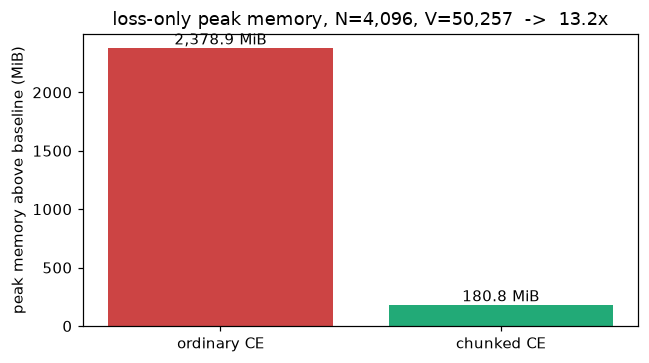

In [18]:
N, Vb, dmem, CH = CFG["mem_rows"], CFG["mem_vocab"], CFG["d_model"], CFG["chunk_rows"]

if DEVICE == "cuda":
    def _peak(mode):
        torch.cuda.empty_cache()
        torch.manual_seed(0)
        hidden = torch.randn(N, dmem, device="cuda", requires_grad=True)
        W = (torch.randn(Vb, dmem, device="cuda") * 0.02).requires_grad_()
        targets = torch.randint(0, Vb, (N,), device="cuda")
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        base = torch.cuda.memory_allocated()          # the inputs themselves
        if mode == "plain":
            plain_ce(hidden, W, targets).backward()
        else:
            chunked_ce(hidden, W, targets, chunk_rows=CH).backward()
        torch.cuda.synchronize()
        return (torch.cuda.max_memory_allocated() - base) / 2**20
    mem_how = "CUDA allocator peak above the resident inputs (byte-exact)"
else:
    DRIVER = CE_IMPL_SRC + r"""
import gc, os, sys, threading, time
mode, N, V, d, chunk = sys.argv[1], int(sys.argv[2]), int(sys.argv[3]), int(sys.argv[4]), int(sys.argv[5])
PAGE = os.sysconf("SC_PAGE_SIZE")


def rss_mib():
    with open("/proc/self/statm") as fh:
        return int(fh.read().split()[1]) * PAGE / 2**20


torch.manual_seed(0)
hidden = torch.randn(N, d, requires_grad=True)
W = (torch.randn(V, d) * 0.02).requires_grad_()
targets = torch.randint(0, V, (N,))

# warm-up OUTSIDE the measured window: spawn the thread pool and its scratch
# buffers once, so only the loss's own allocations are measured below
with torch.no_grad():
    (hidden[:64] @ W[:512].t()).sum()
gc.collect()

state = {"peak": 0.0, "stop": False}


def watch():
    while not state["stop"]:
        state["peak"] = max(state["peak"], rss_mib())
        time.sleep(0.001)


base = rss_mib()
state["peak"] = base
watcher = threading.Thread(target=watch)
watcher.start()
if mode == "plain":
    plain_ce(hidden, W, targets).backward()
else:
    chunked_ce(hidden, W, targets, chunk_rows=chunk).backward()
state["stop"] = True
watcher.join()
print(max(state["peak"], rss_mib()) - base)
"""

    def _peak(mode):
        # MALLOC_MMAP_THRESHOLD_ pins glibc's dynamic mmap threshold, so freed
        # chunk buffers are returned to the OS immediately and the resident set
        # tracks the allocator instead of heap fragmentation.
        env = {**os.environ, "MALLOC_MMAP_THRESHOLD_": "131072"}
        out = subprocess.run([sys.executable, "-c", DRIVER, mode,
                              str(N), str(Vb), str(dmem), str(CH)],
                             capture_output=True, text=True, check=True, env=env)
        return float(out.stdout.strip())               # MiB of RSS growth
    mem_how = ("resident-set growth during the loss call, sampled at 1 kHz, "
               "one fresh subprocess per variant (glibc mmap threshold pinned)")

peak_plain = _peak("plain")
peak_chunked = _peak("chunked")
ratio = peak_plain / max(peak_chunked, 1e-9)
logits_mib = N * Vb * 4 / 2**20
chunk_mib = CH * Vb * 4 / 2**20

print(f"measurement: {mem_how}  (device={DEVICE}, N={N:,}, V={Vb:,}, d={dmem})")
print(f"analytic: full logits {N:,}x{Vb:,}x4B = {logits_mib:,.1f} MiB; "
      f"one chunk {CH}x{Vb:,}x4B = {chunk_mib:,.1f} MiB")
print(f"ordinary CE, loss-attributable peak : {peak_plain:,.1f} MiB")
print(f"chunked  CE, loss-attributable peak : {peak_chunked:,.1f} MiB")
print(f"ratio ordinary/chunked              : {ratio:,.1f}x")

(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 3.4), dpi=110)
bars = ax.bar(["ordinary CE", "chunked CE"], [peak_plain, peak_chunked],
              color=["#c44", "#2a7"])
for b, v in zip(bars, [peak_plain, peak_chunked]):
    ax.annotate(f"{v:,.1f} MiB", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom")
ax.set_ylabel("peak memory above baseline (MiB)")
ax.set_title(f"loss-only peak memory, N={N:,}, V={Vb:,}  ->  {ratio:,.1f}x")
fig.tight_layout()
fig.savefig(ART / "plots" / "memory_bars.png")
plt.show()

RESULTS["part1"]["memory"] = {
    "device": DEVICE, "how": mem_how, "N": N, "V": Vb, "d": dmem,
    "chunk_rows": CH,
    "peak_full_mb": peak_plain, "peak_chunked_mb": peak_chunked, "ratio": ratio,
    "analytic_logits_mb": logits_mib, "analytic_chunk_mb": chunk_mib,
}
HEADLINE["mem_full_mb"] = f"{peak_plain:,.1f}"
HEADLINE["mem_chunked_mb"] = f"{peak_chunked:,.1f}"
HEADLINE["mem_ratio"] = f"{ratio:,.1f}"

## §10 — Part 2: a second head predicting t+2

A second linear head is bolted onto the *same* trunk — this is the parallel-heads
multi-token-prediction design of Gloeckle et al. (arXiv:2404.19737); DeepSeek-V3
(arXiv:2412.19437) uses a heavier sequential variant of the same idea. The alignments:

- head 1: `logits1[:, :-1]` answers for `tokens[:, 1:]` — the next token,
- head 2: `logits2[:, :-2]` answers for `tokens[:, 2:]` — the token after next
  (two prediction slots are lost at the end of the sequence, and any padding/boundary
  mask would shift by two identically).

Training minimizes the plain sum `L1 + L2` for 600 steps, logging each loss separately on
the training stream and on the two held-out documents.

**What to expect, and why.** At the first log point the two heads are indistinguishable
— still at the ignorance plateau, gap ≈ 0 — because before the model knows anything, one
step ahead and two steps ahead are equally unknowable. Then both losses fall, and a gap
**opens with `L2` above `L1`**: predicting `t+2` means marginalizing over the unknown
token in between, and conditioning on strictly less information can never help —
`H(x_{t+2} | x_{≤t}) ≥ H(x_{t+2} | x_{≤t+1})`, and the right-hand side is head 1's own
task one step later (by stationarity). The gap *is* the information carried by the
skipped token, and the model has to learn the language before that information is worth
anything — which is why the gap grows as the losses shrink. Watch the two splits
separately: on the **held-out** documents the gap keeps growing late into training — the
entropy argument is about the language, and generalization cannot cheat it. On the
**training** stream, where an over-parameterized model slowly memorizes the ~6.6 KB
corpus, the gap stops growing and plateaus below the held-out gap — memorization makes
the skipped token partly known, capping what the gap can be made of. That asymmetry is
the memorization signature, reported rather than averaged away.

  step    1  loss=11.0611  L1=5.5193 L2=5.5418


  step   20  loss=6.1255  L1=3.0644 L2=3.0611


  step   40  loss=6.0401  L1=3.0222 L2=3.0179


  step   60  loss=5.8469  L1=2.9012 L2=2.9457


  step   80  loss=5.7037  L1=2.7557 L2=2.9481


...

  step  520  loss=4.8581  L1=2.2834 L2=2.5747


  step  540  loss=4.7451  L1=2.2208 L2=2.5243


  step  560  loss=4.9333  L1=2.3049 L2=2.6284


  step  580  loss=4.6981  L1=2.2284 L2=2.4696


  step  600  loss=4.9444  L1=2.3297 L2=2.6148

final train : L1=2.3297  L2=2.6148  sum=4.9444
final held  : L1=2.5924  L2=2.9745  sum=5.5668
held-out gap L2-L1: -0.0056 at first log -> 0.3821 at the end


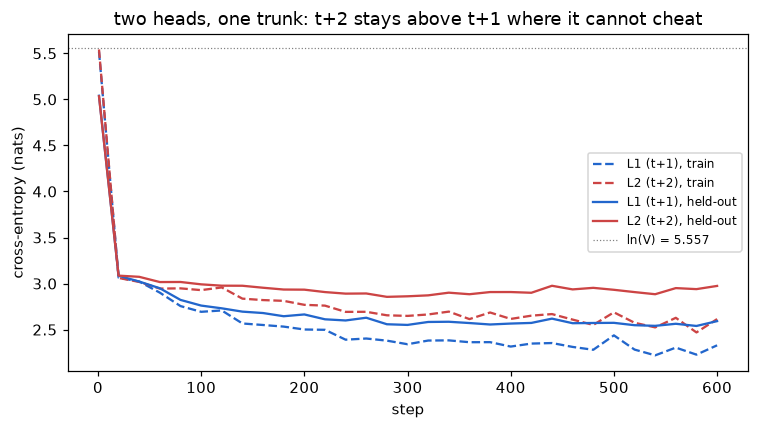

In [19]:
model_mtp, curve_mtp = train_arm("correct", CFG["steps_part2"], two_heads=True)
CURVES["part2"] = curve_mtp

f_tr_L1, f_tr_L2 = curve_mtp["train_L1"][-1], curve_mtp["train_L2"][-1]
f_hd_L1, f_hd_L2 = curve_mtp["held_L1"][-1], curve_mtp["held_L2"][-1]
gap_first = curve_mtp["held_L2"][0] - curve_mtp["held_L1"][0]
gap_last = f_hd_L2 - f_hd_L1

print(f"\nfinal train : L1={fmt(f_tr_L1)}  L2={fmt(f_tr_L2)}  sum={fmt(f_tr_L1 + f_tr_L2)}")
print(f"final held  : L1={fmt(f_hd_L1)}  L2={fmt(f_hd_L2)}  sum={fmt(f_hd_L1 + f_hd_L2)}")
print(f"held-out gap L2-L1: {fmt(gap_first)} at first log -> {fmt(gap_last)} at the end")

(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
s = curve_mtp["step"]
ax.plot(s, curve_mtp["train_L1"], "--", color="#26c", label="L1 (t+1), train")
ax.plot(s, curve_mtp["train_L2"], "--", color="#c44", label="L2 (t+2), train")
ax.plot(s, curve_mtp["held_L1"], "-", color="#26c", label="L1 (t+1), held-out")
ax.plot(s, curve_mtp["held_L2"], "-", color="#c44", label="L2 (t+2), held-out")
ax.axhline(math.log(VOCAB_SIZE), color="gray", lw=0.8, ls=":",
           label=f"ln(V) = {math.log(VOCAB_SIZE):.3f}")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy (nats)")
ax.set_title("two heads, one trunk: t+2 stays above t+1 where it cannot cheat")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ART / "plots" / "mtp_gap.png")
plt.show()

RESULTS["part2"] = {
    "final": {"train_L1": f_tr_L1, "train_L2": f_tr_L2,
              "train_sum": f_tr_L1 + f_tr_L2,
              "held_L1": f_hd_L1, "held_L2": f_hd_L2,
              "held_sum": f_hd_L1 + f_hd_L2},
    "held_gap_first_log": gap_first, "held_gap_final": gap_last,
}
for k, v in RESULTS["part2"]["final"].items():
    HEADLINE[f"p2_{k}"] = fmt(v)

## §11 — Part 3: the bug zoo, or why a beautiful curve proves nothing

Same architecture, same initialization, same crop sequence, same optimizer, same budget as
the §4 correct arm. The three arms differ **only** in the two slicing lines:

| arm | prediction slice | target slice | what position *t* is asked |
|---|---|---|---|
| `correct` | `logits[:, :-1]` | `tokens[:, 1:]` | the token it has **not** seen |
| `reversed` | `logits[:, 1:]` | `tokens[:, :-1]` | the token it read **one step ago** |
| `no_shift` | `logits` | `tokens` | the token **in its own input** |

Both bugs hand the network a target that already sits inside its receptive field, so the
optimizer finds the copy circuit almost immediately. The result is the assignment's
warning, quantified: **all three curves fall smoothly (batch-to-batch jitter aside), and
the two broken ones end *lower* than the correct one.** If loss going down is your only
instrument, the bugs don't just hide — they *outshine* the truth.

Two instruments do distinguish them, and both are cheap:

1. **`audit_shift`** — the §4 string audit, run on each arm's actual `(input, target)`
   tensors. One screen of strings names each bug exactly.
2. **Behavior** — 200 tokens sampled at temperature 0.8 (seeded, deterministic). The
   correct arm rambles imperfectly but *in corpus register*; the copy circuits, fed their
   own output, collapse into repetition of whatever they emit first. The character-4-gram
   hit rate against the corpus turns that judgment into a number.

In [20]:
model_rev, curve_rev = train_arm("reversed", CFG["steps_zoo"], quiet=True)
model_nos, curve_nos = train_arm("no_shift", CFG["steps_zoo"], quiet=True)
CURVES["zoo_reversed"], CURVES["zoo_no_shift"] = curve_rev, curve_nos

zoo_models = {"correct": model_correct, "reversed": model_rev, "no_shift": model_nos}
zoo_curves = {"correct": curve_correct, "reversed": curve_rev, "no_shift": curve_nos}

seed_all()
probe = sample_batch(TRAIN_STREAM, CFG["B"], CFG["T"], random.Random(SEED + 3))
zoo = {}
for name in ("correct", "reversed", "no_shift"):
    print("=" * 72)
    a = audit_shift(probe, ARMS[name], title=f"{name} arm")
    ids = generate(zoo_models[name])
    text = decode(ids)
    rate = four_gram_hit_rate(text, CORPUS_TEXT)
    print(f"  first tokens emitted: {' '.join(decode_token(t) for t in ids[1:13])}")
    print(f"  sampled text (T=0.8): {text[:70]!r}")
    print(f"  4-gram hit rate vs corpus: {rate:.3f}")
    zoo[name] = {"final_loss": zoo_curves[name]["loss"][-1],
                 "verdict": a["verdict"], "rates": a["rates"],
                 "gram4": rate, "sample": text[:120]}

print("=" * 72)
print(f"{'arm':<10} {'final loss':>10} {'verdict':>10} {'4-gram':>8}")
for name, z in zoo.items():
    print(f"{name:<10} {fmt(z['final_loss']):>10} {z['verdict']:>10} {z['gram4']:>8.3f}")

shift audit: correct arm
  position: 0 1 2 3 4 5 6 7 8 910111213
  input   : f ␣ o n e ␣ e s s a y ␣ p r   (last token read)
  target  : ␣ o n e ␣ e s s a y ␣ p r e   (token demanded)
  match rate reversed(-1): 0.0268
  match rate  identity(0): 0.0157
  match rate  correct(+1): 1.0000
  verdict: CORRECT


  first tokens emitted: t ␣ i g e e s ␣ t ␣ t i
  sampled text (T=0.8): 't igees t tiritarondnd th tinonict monts whe the le ikathe cos ist imu'
  4-gram hit rate vs corpus: 0.284
shift audit: reversed arm
  position: 1 2 3 4 5 6 7 8 91011121314
  input   : ␣ o n e ␣ e s s a y ␣ p r e   (last token read)
  target  : f ␣ o n e ␣ e s s a y ␣ p r   (token demanded)
  match rate reversed(-1): 1.0000
  match rate  identity(0): 0.0157
  match rate  correct(+1): 0.0268
  verdict: REVERSED


  first tokens emitted: <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>
  sampled text (T=0.8): ''
  4-gram hit rate vs corpus: 0.000
shift audit: no_shift arm
  position: 0 1 2 3 4 5 6 7 8 910111213
  input   : f ␣ o n e ␣ e s s a y ␣ p r   (last token read)
  target  : f ␣ o n e ␣ e s s a y ␣ p r   (token demanded)
  match rate reversed(-1): 0.0157
  match rate  identity(0): 1.0000
  match rate  correct(+1): 0.0157
  verdict: IDENTITY


  first tokens emitted: <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>
  sampled text (T=0.8): ''
  4-gram hit rate vs corpus: 0.000
arm        final loss    verdict   4-gram
correct        2.3386    CORRECT    0.284
reversed       0.0045   REVERSED    0.000
no_shift       0.0000   IDENTITY    0.000


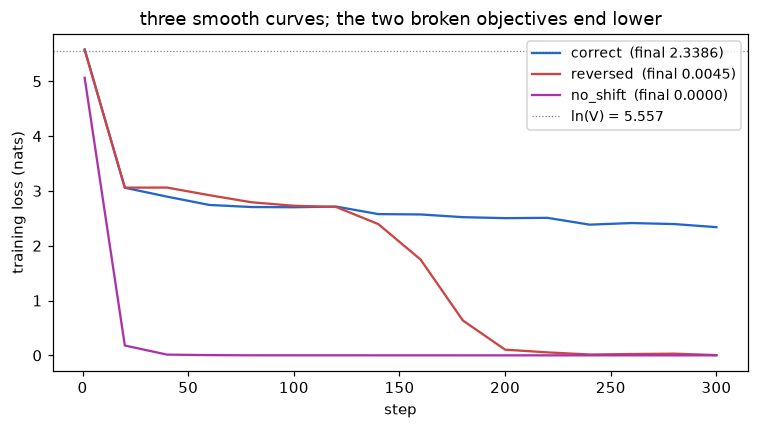

In [21]:
(ART / "plots").mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4), dpi=110)
colors = {"correct": "#26c", "reversed": "#c44", "no_shift": "#a3a"}
for name, c in zoo_curves.items():
    ax.plot(c["step"], c["loss"], color=colors[name],
            label=f"{name}  (final {fmt(c['loss'][-1])})")
ax.axhline(math.log(VOCAB_SIZE), color="gray", lw=0.8, ls=":",
           label=f"ln(V) = {math.log(VOCAB_SIZE):.3f}")
ax.set_xlabel("step"); ax.set_ylabel("training loss (nats)")
ax.set_title("three smooth curves; the two broken objectives end lower")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(ART / "plots" / "bug_zoo_curves.png")
plt.show()

RESULTS["part3"] = {"arms": zoo}
for name, z in zoo.items():
    HEADLINE[f"zoo_{name}_final"] = fmt(z["final_loss"])
    HEADLINE[f"zoo_{name}_gram4"] = f"{z['gram4']:.3f}"

## §12 — Every number, written to disk

`submission_artifacts/results.json` holds the seven Part-1 numbers, Part 2's losses, and
the Part-3 table; `loss_curves.json` the raw curves; `per_token_losses.json` the raw
per-token vectors behind §5/§6. The repo's `audit.py` re-derives each claim from these
files without executing this notebook, and checks that every `headline` value below
appears **verbatim** in the README — nothing in the write-up is retyped by hand.

In [22]:
RESULTS["wall_seconds"] = round(time.time() - T0, 1)
RESULTS["headline"] = HEADLINE

ART.mkdir(parents=True, exist_ok=True)
(ART / "results.json").write_text(json.dumps(RESULTS, indent=2))
(ART / "loss_curves.json").write_text(json.dumps(CURVES, indent=2))
(ART / "per_token_losses.json").write_text(json.dumps(PTL, indent=2))
(ART / "run_config.json").write_text(json.dumps(RESULTS["config"], indent=2))

p1 = RESULTS["part1"]
print("the seven numbers (Part 1):")
print(f"  1. logits shape {tuple(p1['shapes']['logits'])}  "
      f"[B sequences, T positions, V vocabulary scores]")
print(f"  2. shift audit: correct(+1) match rate {HEADLINE['shift_rate_correct']}")
print(f"  3. contributing targets {HEADLINE['pad_slots']} -> {HEADLINE['pad_contributing']}"
      f"  (loss {HEADLINE['pad_loss_unmasked']} -> {HEADLINE['pad_loss_masked']})")
print(f"  4. packed loss {HEADLINE['pack_loss_before']} -> {HEADLINE['pack_loss_after']}"
      f"  after masking {p1['packing']['n_boundary']} boundary targets")
print(f"  5. untrained perplexity {HEADLINE['untrained_ppl']}  (V = {VOCAB_SIZE})")
print(f"  6. params tied {HEADLINE['params_tied']} vs untied {HEADLINE['params_untied']}"
      f"  (delta {HEADLINE['params_delta']} = V*d)")
print(f"  7. loss peak memory {HEADLINE['mem_full_mb']} MiB -> "
      f"{HEADLINE['mem_chunked_mb']} MiB  (ratio {HEADLINE['mem_ratio']}x)")
print("Part 2:")
print(f"  held-out L1 {HEADLINE['p2_held_L1']}  L2 {HEADLINE['p2_held_L2']}"
      f"  sum {HEADLINE['p2_held_sum']}")
print("Part 3:")
print(f"  correct {HEADLINE['zoo_correct_final']} / reversed {HEADLINE['zoo_reversed_final']}"
      f" / no_shift {HEADLINE['zoo_no_shift_final']}  (lower is NOT better)")
print(f"\nwall time: {RESULTS['wall_seconds']}s on {DEVICE}")
print("NOTEBOOK COMPLETE")

the seven numbers (Part 1):
  1. logits shape (8, 128, 259)  [B sequences, T positions, V vocabulary scores]
  2. shift audit: correct(+1) match rate 1.0000
  3. contributing targets 508 -> 186  (loss 10.4337 -> 2.3146)
  4. packed loss 2.5550 -> 2.5357  after masking 2 boundary targets
  5. untrained perplexity 262.2  (V = 259)
  6. params tied 495,488 vs untied 528,640  (delta 33,152 = V*d)
  7. loss peak memory 2,378.9 MiB -> 180.8 MiB  (ratio 13.2x)
Part 2:
  held-out L1 2.5924  L2 2.9745  sum 5.5668
Part 3:
  correct 2.3386 / reversed 0.0045 / no_shift 0.0000  (lower is NOT better)

wall time: 76.2s on cpu
NOTEBOOK COMPLETE
